# Problem Set 3 - Random Numbers - comments/solutions

# Programming for Economists Summer 2026: Class 9
**Matias BF Hall**

**Table of contents**<a id='toc0_'></a>    
- 1. [RNG Warm-up (Reproducibility Basics)](#toc1_)    
- 2. [Drawing from a Pareto distribution](#toc2_)    
- 3. [Unemployment](#toc3_)    
- 4. [Many workers: Unemployment](#toc4_)    
- 5. [Deterministic simulation with transition matrix](#toc5_)    
- 6. [Diversification: Two correlated stocks](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. <a id='toc1_'></a>[RNG Warm-up (Reproducibility Basics)](#toc0_)

**Goal.** Create reproducible draws; understand *seed vs stream*.

- Create `rng = np.random.default_rng(2025)`.
- Draw 5 uniforms and 5 normals.
- Re-create the same sequence by constructing a **new** generator with the same seed.
- Show that **calling the same generator twice** advances the stream (different outputs).



In [2]:
# Starter (safe to run)
rng = np.random.default_rng(2025)
u1 = rng.random(5)
z1 = rng.standard_normal(5)

rng_same = np.random.default_rng(2025)
# Task: Reproduce the first draws from the same seed
u2 = rng_same.random(5)
z2 = rng_same.standard_normal(5)

# Stream progression (same generator again)
u_next = rng.random(5)
z_next = rng.standard_normal(5)

# Print first draws
print("First uniform draws u1:", u1)
print("First standard normal draws z1:", z1)

# Check that u1 equals u2 and z1 equals z2
print("u1 equals u2:", np.allclose(u1, u2))
print("z1 equals z2:", np.allclose(z1, z2))

# Print the next draws
print("Next uniform draws:", u_next)
print("Next standard normal draws:", z_next)


# As we see the draws where we refresh the generator with the same seed are identical
# The next draws continue the sequence from the first generator
# That is we have moved down the stream after the first 5 draws,
# so even though we started at the same seed, the next draws are different

First uniform draws u1: [0.99445781 0.38200974 0.82714801 0.83725528 0.97580901]
First standard normal draws z1: [ 0.7653914  -0.75970935  0.26699619  0.70178085  0.29212132]
u1 equals u2: True
z1 equals z2: True
Next uniform draws: [0.38954302 0.23021956 0.16696115 0.15343643 0.9740917 ]
Next standard normal draws: [-0.3924407  -0.67731696  2.93601077 -0.66462723  1.25746344]


## 2. <a id='toc2_'></a>[Drawing from a Pareto distribution](#toc0_)

**Goal.** Get familiar with drawing from a non-normal distribution and visualising its heavy tail.

The Pareto distribution is a classic model of "fat-tailed" data (wealth, city sizes, firm sizes). With shape parameter $b$ and minimum value $x_m=1$ the fraction of draws above $x$ is
$$P(X>x) = x^{-b},\qquad x\ge 1.$$

**Tasks.**
1. Draw `size=10_000` numbers from a Pareto distribution with shape `b=2.0` using a local generator. 

    *Hint:* `rng.pareto(b, size) + 1.0` gives the classic Pareto with $x_m=1$.

2. Plot a **histogram** of `log(draws)`.

3. Plot the **tail** (the empirical fraction of draws above $x$, $P(X>x)$) on **log-log axes**. For a Pareto it should look like a straight line.

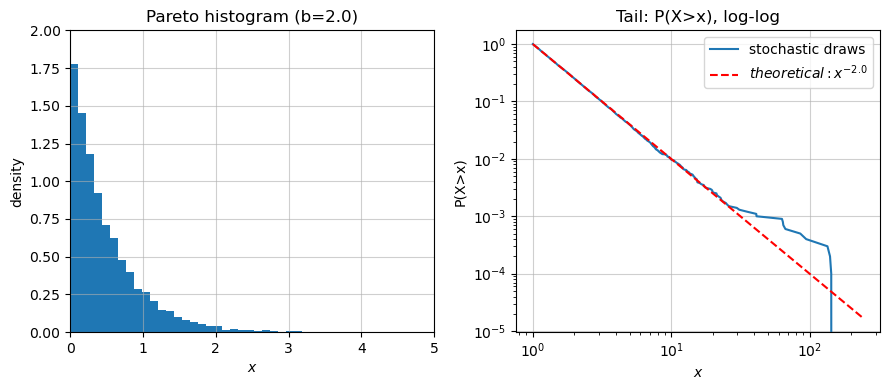

In [3]:
# write your own code here

# define the pareto variables
size = 10_000
b = 2.0

# restart rng for reproducibility
rng = np.random.default_rng(2025)
# generate pareto draws using hint above
pareto_draws = rng.pareto(b, size) + 1.0

# create plot
fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharex=False)

# histogram created to look like Jeppe's
axs[0].hist(np.log(pareto_draws), bins=50, density=True)
axs[0].set_title(f'Pareto histogram (b={b})')
axs[0].set_xlabel(f'$x$')
axs[0].set_ylabel('density')
axs[0].set_xlim(0, 5)
axs[0].set_ylim(0, 2)
axs[0].grid(True, alpha=0.6)

# tail created to look like Jeppe's
draws_sorted = np.sort(pareto_draws) # sort draws so the line does not jump
axs[1].loglog(draws_sorted, 1 - np.arange(1, size + 1) / size, label='stochastic draws') # the y-value is created by the rank of the draw, which is 1 - (rank / size).
axs[1].loglog(draws_sorted, draws_sorted**(-b), label=f'$theoretical: x^{{-{b}}}$', linestyle='--',c='red') # theoretical tail
axs[1].set_title(f'Tail: P(X>x), log-log')
axs[1].set_xlabel(f'$x$')
axs[1].set_ylabel('P(X>x)')
axs[1].grid(True, alpha=0.6)
axs[1].legend()
fig.tight_layout()
plt.show();

***Note:*** Since I used a different seed than Jeppe, the plots will not be the same. Change the seed to 2026, to make them the same.

## 3. <a id='toc3_'></a>[Unemployment](#toc0_)

**Goal.** Simulate a single worker who is hit by random shocks each period:

- If **Employed** ($E$), a bad shock causes separation to **Unemployment** ($U$) with probability $s$.
- If **Unemployed** ($U$), a good shock leads to job finding back to $E$ with probability $f$.

Encode $0=E$, $1=U$ so that the average of the path is directly the unemployment share.

**Intuition.** Each period a worker is in one state. A *transition probability* tells you how likely it is to switch next period ($s$ is the job-separation rate, $f$ the job-finding rate). Simulating just means: draw a uniform $u\sim U[0,1]$ and compare it to the relevant probability to decide the next state.

**Task: Implement the following**

1. Pick inputs: horizon $T$, separation probability $s$, job-finding probability $f$, initial state $s_0\in\{0,1\}$ (encode $0=E$, $1=U$), and a seed.
2. For each period $t=0,\dots,T-1$, draw one uniform $\epsilon_t\sim U[0,1]$ and apply:
   - If in $E$: set next state to $U$ if $\epsilon_t<s$, else stay in $E$.
   - If in $U$: set next state to $E$ if $\epsilon_t<f$, else stay in $U$.
3. Store the whole path of length $T+1$ and report the share of time in $U$ (the mean, since $U=1$).

**Hints**
- Use $0=E$, $1=U$ so averages give unemployment directly.
- One fresh random draw per period.
- Start small ($T=20$) to print and check; then scale up.
- Set a seed for reproducibility while debugging.

In [4]:
# Set the number of periods, and workers, T and N
# Also defining E and U, and s, f and s0
T = 1_000
N = 1
E = 0.0
U = 1.0
s = 0.02
f = 0.3
s0 = 0


# This is a very basic and slow function where I loop over each period and each worker
# See the exercise solution for a more efficient vectorized version
def unemployment_simulation(T, N, s, f,s0):
    # Simulate productivity draws for N workers over T periods
    # Initialize random number generator for replicability
    rng = np.random.default_rng(2026)
    draw = rng.random((T, N))

    # initialise state arrays with the initial state s0
    states = np.full((T+1, N),s0)

    # we loop over each period
    for t in range(T):
        # and each worker
        for n in range(N):
            if states[t, n] == E:
                # if employed, check if they become unemployed
                if draw[t, n] < s:
                    states[t+1, n] = U
                else:
                    states[t+1, n] = E
            else:
                # if unemployed, check if they become employed
                if draw[t, n] < f:
                    states[t+1, n] = E
                else:
                    states[t+1, n] = U
    return states, draw

# Run the simulation
states, draws = unemployment_simulation(T, N, s, f,s0)

# Print the states and draws and unemployment rate
print(f'First 10 shocks (uniform): {np.round(draws[:10, 0], 3)}')
print(f'First 10 states: {np.round(states[:10, 0], 4)}')
print(f'unemployment rate: {np.mean(states):.4f}')


First 10 shocks (uniform): [0.179 0.64  0.467 0.371 0.355 0.791 0.905 0.177 0.653 0.298]
First 10 states: [0 0 0 0 0 0 0 0 0 0]
unemployment rate: 0.0579


## 4. <a id='toc4_'></a>[Many workers: Unemployment](#toc0_)

Simulate $N$ (e.g. 50,000) workers in parallel (one uniform draw per worker per period) and track the unemployment rate over time. With many workers the cross-sectional unemployment rate settles down close to the theoretical value $\pi_U^*=\frac{s}{s+f}$.

Plot the unemployment rate against time to see it settle down from the initial condition (all workers start employed) toward $\pi_U^*$. The early periods, before the rate has converged, are the **burn-in**: because every worker starts in the same state, this initial transition is not representative of the long-run (steady-state) behaviour and is typically discarded before computing a time average.

In [5]:
# set the number of periods, and workers, T and N
# we want at least 1000 periods to have a long burn-in period, and N is set as suggested.
# I don't set T higher than 2000 due to the inefficiency of the function above, but it is feasible to set T higher if you use a vectorized version of the function.
T = 2_000
N = 50_000

# Use the function above
states, draws = unemployment_simulation(T, N, s, f, s0)

# compute the average unemployment rate over time, axis one so we get the average across all workers for each period
u_rate_periods = np.mean(states[1000+1:,:], axis=1)

# compute theoretical unemployment rate:
u_theoretical = s / (s + f)

# prints
print(f'First 10 unemployment rates: {np.round(np.mean(states[:10, :], axis=1), 4)}')
print(f'Last 10 unemployment rates: {np.round(np.mean(states[-10:, :], axis=1), 4)}')
print(f'Average unemployment rate after burn-in (T>1000): {np.round(np.mean(u_rate_periods), 4)}')
print(f'Theoretical unemployment rate: {np.round(u_theoretical, 4)}')


First 10 unemployment rates: [0.     0.0202 0.0343 0.0431 0.0495 0.0528 0.0562 0.0586 0.06   0.0611]
Last 10 unemployment rates: [0.0611 0.0616 0.0612 0.0618 0.0617 0.0625 0.0627 0.0626 0.0614 0.0619]
Average unemployment rate after burn-in (T>1000): 0.0626
Theoretical unemployment rate: 0.0625


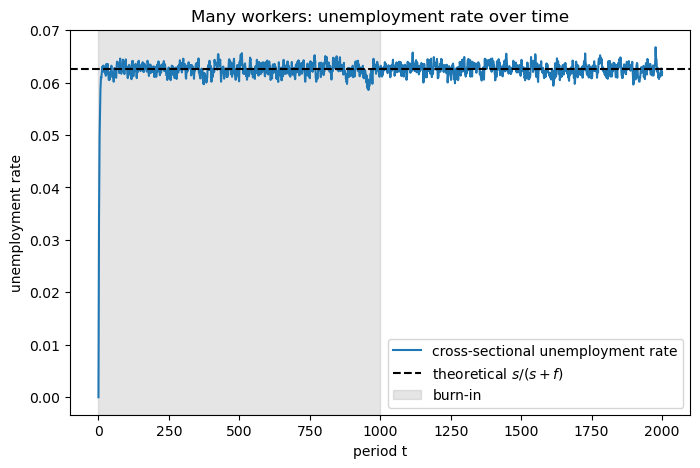

In [6]:
# plot using Jeppe's code with my variable names

burn_in = 1000
u_rate = np.mean(states, axis=1)
t = np.arange(u_rate.size)
pi_star = s / (s + f)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, u_rate, label='cross-sectional unemployment rate')
ax.axhline(pi_star, ls='--', color='black', label=r'theoretical $s/(s+f)$')
if burn_in > 0:
    ax.axvspan(0, burn_in, color='grey', alpha=0.2, label='burn-in')
ax.set_xlabel('period t')
ax.set_ylabel('unemployment rate')
ax.set_title('Many workers: unemployment rate over time')
ax.legend()
plt.show()

## 5. <a id='toc5_'></a>[Deterministic simulation with transition matrix](#toc0_)

Now collect the two hazards into a transition matrix. Let $s\in(0,1)$ be the separation probability (E→U) and $f\in(0,1)$ the job-finding probability (U→E):
$$
P = \begin{pmatrix}
1-s & s\\
f & 1-f
\end{pmatrix}.
$$

**Matrix interpretation**
- States: `E=0` (employed), `U=1` (unemployed).
- Rows = current state, columns = next state.
- $P$ is **row-stochastic**: each row sums to 1 and all entries are in $[0,1]$.

Let $\pi_t=(\pi_{t,E},\pi_{t,U})$ be the **population distribution** at time $t$: a row vector giving the share of workers in each state, so $\pi_{t,E}+\pi_{t,U}=1$. 

$\pi_0$ is just this distribution at $t=0$ — e.g. $\pi_0=(1,0)$ means everyone starts employed.

**Your tasks**
1. Implement `make_P(s, f)` returning the matrix above and validate it (entries in $[0,1]$, rows sum to 1).
2. Use $P$ to run a **deterministic** simulation of the population shares: starting from $\pi_0$, iterate $\pi_{t+1}=\pi_t P$. No random numbers are involved. Check that the unemployment share converges to the **same** value as the stochastic simulation above and to the theoretical $\frac{s}{s+f}$.

In [7]:
# Very little adjustment from the given starter code
def make_P(s, f):
    """Return a 2x2 row-stochastic transition matrix for E=0, U=1.
    """
    assert 0.0 <= s <= 1.0 and 0.0 <= f <= 1.0, "Probabilities must be in [0,1]."
    # TODO: implement
    P = np.array([[1.0-s, s],
                  [f, 1.0-f]], dtype=float)
    assert np.allclose(P.sum(axis=1), 1.0), "Rows must sum to 1."
    return P

# Validator will be defined in solution; checks follow there.


In [8]:
# This functions computes the stationary (deterministic) distribution of unemployment and returns how many periods it takes from an initial state pi0
def stationary_power(P,tol=1e-12,maxit=1_000_000,pi0=None):
    #if no initial distribution is given, start with uniform
    if pi0 is None:
        pi0 = np.ones(P.shape[0]) / P.shape[0]
    it = 0
    # loop until convergence or max iterations reached
    while it < maxit:
        pi = pi0 @ P
        if np.linalg.norm(pi - pi0,ord=np.inf) < tol: # if the state barely changes, we have converged, checks if the maximum absolute difference between the new and old state is less than the tolerance
            return pi, it
        # update for next iteration
        pi0 = pi
        it += 1
    print("Max iterations reached")
    return pi, maxit

In [9]:
# set s and f and compute P
s = 0.02
f = 0.3
P = make_P(s, f)

# compute stationary distribution and theoretical
pi, iterations = stationary_power(P,pi0=np.array([1.0, 0.0])) # start with all employed

pi_U_theory = s/(s + f)

# compare and print results
assert np.isclose(pi[1], pi_U_theory), "Stationary unemployment rate does not match theory."
print(P)
print(f"Stationary distribution computed in {iterations} iterations: {pi}")

[[0.98 0.02]
 [0.3  0.7 ]]
Stationary distribution computed in 62 iterations: [0.9375 0.0625]


***Comment*** I use a slightly different method than Jeppe, and don't report how the distribution changes as we iterate through. But we get the same conclussion that the deterministic distribution is the same as the theoretical.

## 6. <a id='toc6_'></a>[Diversification: Two correlated stocks](#toc0_)

**Goal.** Use Monte Carlo simulation (as in lecture 6) to show the **value of diversification**: splitting your money across two imperfectly correlated stocks lowers risk without lowering the expected return.

**Setup.** Two stocks have the *same* expected annual return $\mu$ and the *same* volatility $\sigma$, but their returns are correlated with coefficient $\eta$. Their (random) annual returns are
$$r_A = \mu + \sigma z_1,\qquad r_B = \mu + \sigma\,(\eta\, z_1 + \sqrt{1-\eta^2}\, z_2),$$
where $z_1, z_2$ are independent standard normals. (This is a simple way to build two correlated normals from independent draws.) 

An equal-weighted portfolio earns $r_P = \tfrac12 r_A + \tfrac12 r_B$.

**Tasks.**
1. Write a function that, given a correlation $\eta$, simulates `n_worlds` draws of $(r_A, r_B)$, forms the equal-weighted portfolio, and returns the **standard deviation** of $r_P$ across worlds. Vectorize over worlds (no Python loop over draws).
2. Check that the portfolio's **mean** return is still $\approx \mu$, but its **standard deviation** is below the single-stock $\sigma$ (for $\eta < 1$).
3. Sweep $\eta$ from $-1$ to $1$ and plot the Monte Carlo portfolio volatility against $\eta$. Overlay the single-stock level $\sigma$.

**Hints.**
- Use one local generator `rng = np.random.default_rng(seed)`.
- Draw `z1 = rng.normal(size=n_worlds)` and `z2 = rng.normal(size=n_worlds)`.
- Suggested parameters: $\mu=0.08$, $\sigma=0.20$, `n_worlds = 100_000`.

In [10]:
mu = 0.08
sigma=0.20
n_worlds = 100_000

# create array of etas
etas = np.linspace(-1, 1, 20)

# write your own code here
def diversification_simulation(mu, sigma, n_worlds,etas,seed=2026):

    # Simulate normally distributed returns for n_worlds
    rng = np.random.default_rng(seed)
    z1 = rng.normal(size=n_worlds)
    z2 = rng.normal(size=n_worlds)

    # create stocks and diversified portfolio (using formulas above)
    ra = mu + sigma*z1
    rb = mu + sigma*(etas*z1[:, np.newaxis] + np.sqrt(1-etas**2)*z2[:, np.newaxis]) # we use newaxis to add an extra dimension to z1 and z2 so they can broadcast with etas
    rn = (ra[:, np.newaxis] + rb)/2 # again newaxis is used so ra and rb can broadcast together
    # you could also write [:,None] instead of [:, np.newaxis], they are equivalent
    
    # Compute the average return and standard deviation
    avg_return = np.mean(rn,axis=0) # axis=0 to compute average across worlds for each eta
    std_dev = np.std(rn,axis=0) # axis=0 to compute std dev across worlds for each eta
    
    return avg_return, std_dev

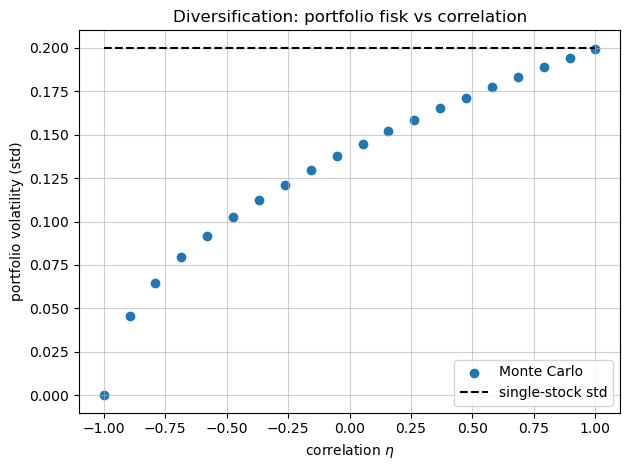

In [11]:
# use function and make the plot
diversified_avg_return, diversified_std_dev = diversification_simulation(mu, sigma, n_worlds,etas)

plt.scatter(etas, diversified_std_dev, label='Monte Carlo')
plt.plot([-1,1], [sigma, sigma], label='single-stock std', linestyle='--',c='black')
plt.xlabel('correlation ${\\eta}$')
plt.ylabel('portfolio volatility (std)')
plt.title('Diversification: portfolio fisk vs correlation')
plt.grid(True, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()